# Build Off-Ball Run Dataset (All Matches)

This notebook loads all matches from the SkillCorner Open Data repository and extracts off-ball run events across the entire dataset.

# Build Off-Ball Run Dataset (All Matches)

In [4]:
import pandas as pd
import os

## Clone SkillCorner Open Data Repository

In [5]:
!git clone https://github.com/SkillCorner/opendata.git

Cloning into 'opendata'...
remote: Enumerating objects: 454, done.
remote: Counting objects: 100% (257/257), done.
remote: Compressing objects: 100% (149/149), done.
remote: Total 454 (delta 92), reused 216 (delta 68), pack-reused 197 (from 1)
Receiving objects: 100% (454/454), 159.32 MiB | 16.29 MiB/s, done.
Resolving deltas: 100% (165/165), done.
Filtering content: 100% (10/10), 873.32 MiB | 34.82 MiB/s, done.


## Locate Match Folders

In [6]:
matches_dir = "opendata/data/matches"
os.listdir(matches_dir)

['1886347',
 '2006229',
 '2011166',
 '1899585',
 '2017461',
 '1925299',
 '2013725',
 '1953632',
 '1996435',
 '2015213']

## Load Dynamic Events From All Matches

In [7]:
all_events = []

for match_id in os.listdir(matches_dir):

    file_path = f"{matches_dir}/{match_id}/{match_id}_dynamic_events.csv"

    if os.path.exists(file_path):

        df = pd.read_csv(file_path, low_memory=False)
        df["match_id"] = match_id

        all_events.append(df)

events = pd.concat(all_events, ignore_index=True)

print("Total events:", events.shape)

Total events: (47853, 294)


## Inspect Event Types

In [8]:
events["event_type"].value_counts()

,count
event_type,
passing_option,24374
player_possession,9566
on_ball_engagement,8911
off_ball_run,5002


## Extract Off-Ball Runs

In [9]:
runs = events[events["event_type"] == "off_ball_run"]

In [10]:
runs.shape

(5002, 294)

## Create Clean Run Dataset

In [11]:
runs_df = runs[
    [
        "match_id",
        "player_name",
        "team_shortname",
        "event_subtype",
        "team_in_possession_phase_type",
        "team_out_of_possession_phase_type",
        "xthreat",
        "lead_to_shot",
        "lead_to_goal",
        "frame_start",
        "frame_end",
    ]
].copy()

runs_df.head()

,match_id,player_name,team_shortname,event_subtype,team_in_possession_phase_type,team_out_of_possession_phase_type,xthreat,lead_to_shot,lead_to_goal,frame_start,frame_end
10,1886347,T. Aquilina,Newcastle,pulling_wide,direct,defending_direct,0.0038,False,False,74,90
12,1886347,L. Bayliss,Newcastle,coming_short,direct,defending_direct,0.0051,False,False,81,96
13,1886347,B. Gibson,Newcastle,behind,direct,defending_direct,0.0124,False,False,82,99
16,1886347,F. De Vries,Auckland FC,pulling_wide,build_up,high_block,0.0003,False,False,207,217
29,1886347,J. Brimmer,Auckland FC,support,finish,low_block,0.0123,False,False,300,309


## Inspect Dataset Structure

In [12]:
runs_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5002 entries, 10 to 47844
Data columns (total 11 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   match_id                           5002 non-null   object 
 1   player_name                        5002 non-null   object 
 2   team_shortname                     5002 non-null   object 
 3   event_subtype                      5002 non-null   object 
 4   team_in_possession_phase_type      5002 non-null   object 
 5   team_out_of_possession_phase_type  5002 non-null   object 
 6   xthreat                            5002 non-null   float64
 7   lead_to_shot                       5002 non-null   bool   
 8   lead_to_goal                       5002 non-null   bool   
 9   frame_start                        5002 non-null   int64  
 10  frame_end                          5002 non-null   int64  
dtypes: bool(2), float64(1), int64(2), object(6)
memory usage: 4

## Check Missing Values

In [13]:
runs_df.isnull().sum()

,0
match_id,0
player_name,0
team_shortname,0
event_subtype,0
team_in_possession_phase_type,0
team_out_of_possession_phase_type,0
xthreat,0
lead_to_shot,0
lead_to_goal,0
frame_start,0


## Data Cleaning

In [14]:
# remove rows without a run subtype
runs_df = runs_df.dropna(subset=["event_subtype"])

# fill missing xThreat values
runs_df["xthreat"] = runs_df["xthreat"].fillna(0)

runs_df.head()

,match_id,player_name,team_shortname,event_subtype,team_in_possession_phase_type,team_out_of_possession_phase_type,xthreat,lead_to_shot,lead_to_goal,frame_start,frame_end
10,1886347,T. Aquilina,Newcastle,pulling_wide,direct,defending_direct,0.0038,False,False,74,90
12,1886347,L. Bayliss,Newcastle,coming_short,direct,defending_direct,0.0051,False,False,81,96
13,1886347,B. Gibson,Newcastle,behind,direct,defending_direct,0.0124,False,False,82,99
16,1886347,F. De Vries,Auckland FC,pulling_wide,build_up,high_block,0.0003,False,False,207,217
29,1886347,J. Brimmer,Auckland FC,support,finish,low_block,0.0123,False,False,300,309


## Inspect Run Frequency

In [15]:
runs_df["event_subtype"].value_counts()

,count
event_subtype,
run_ahead_of_the_ball,1378
support,751
coming_short,701
dropping_off,631
cross_receiver,423
behind,363
pulling_wide,344
overlap,153
pulling_half_space,148


## Compute Average Run Value

In [16]:
runs_df.groupby("event_subtype")["xthreat"].mean().sort_values(ascending=False)

,xthreat
event_subtype,
cross_receiver,0.108215
behind,0.050508
run_ahead_of_the_ball,0.019308
underlap,0.018838
support,0.018139
overlap,0.015536
pulling_half_space,0.008151
pulling_wide,0.003867
coming_short,0.002315


## Save Full Run Dataset

In [17]:
runs_df.to_csv("all_runs_dataset.csv", index=False)

In [18]:
# Extract off-ball runs from the full events dataset

runs = events[events["event_type"] == "off_ball_run"].copy()

print("Total off-ball runs:", len(runs))
runs.head()

Total off-ball runs: 5002


,event_id,index,match_id,frame_start,frame_end,frame_physical_start,time_start,time_end,minute_start,second_start,...,xloss_player_possession_end,xloss_player_possession_max,xshot_player_possession_start,xshot_player_possession_end,xshot_player_possession_max,is_player_possession_start_matched,is_player_possession_end_matched,is_previous_pass_matched,is_pass_reception_matched,fully_extrapolated
10,1_0,10,1886347,74,90,NaN,00:06.4,00:08.0,0,6,...,NaN,NaN,NaN,NaN,NaN,True,True,NaN,NaN,NaN
12,1_1,12,1886347,81,96,NaN,00:07.1,00:08.6,0,7,...,NaN,NaN,NaN,NaN,NaN,True,True,NaN,NaN,NaN
13,1_2,13,1886347,82,99,NaN,00:07.2,00:08.9,0,7,...,NaN,NaN,NaN,NaN,NaN,True,True,NaN,NaN,NaN
16,1_3,16,1886347,207,217,NaN,00:19.7,00:20.7,0,19,...,NaN,NaN,NaN,NaN,NaN,True,True,NaN,True,NaN
29,1_4,29,1886347,300,309,NaN,00:29.0,00:29.9,0,29,...,NaN,NaN,NaN,NaN,NaN,True,True,NaN,NaN,NaN


##  Inspect Off-Ball Run Types

In [19]:
runs["event_subtype"].value_counts()

,count
event_subtype,
run_ahead_of_the_ball,1378
support,751
coming_short,701
dropping_off,631
cross_receiver,423
behind,363
pulling_wide,344
overlap,153
pulling_half_space,148


##  Attacking Threat Generated by Off-Ball Runs

In [20]:
run_threat = (
    runs
    .groupby("event_subtype")
    .agg(
        total_runs=("event_subtype", "count"),
        avg_xthreat=("xthreat", "mean"),
        total_xthreat=("xthreat", "sum"),
        shots=("lead_to_shot", "sum"),
        goals=("lead_to_goal", "sum")
    )
    .sort_values("avg_xthreat", ascending=False)
)

run_threat

,total_runs,avg_xthreat,total_xthreat,shots,goals
event_subtype,,,,,
cross_receiver,423,0.108215,45.7750,116,22
behind,363,0.050508,18.3343,62,6
run_ahead_of_the_ball,1378,0.019308,26.6071,153,22
underlap,110,0.018838,2.0722,15,2
support,751,0.018139,13.6227,115,12
overlap,153,0.015536,2.3770,22,3
pulling_half_space,148,0.008151,1.2064,7,0
pulling_wide,344,0.003867,1.3304,12,0
coming_short,701,0.002315,1.6231,8,0


### Initial Insights: Attacking Threat by Run Type

The results show clear differences in the attacking value of different off-ball run types. Cross-receiver runs generate the highest average xThreat, significantly higher than any other run category. These runs typically occur in the penalty area when players attack crosses, which often leads directly to shot opportunities. Runs in behind also generate relatively high threat, as they break the defensive line and create dangerous situations closer to goal.

In contrast, runs such as coming short, dropping off, and pulling wide produce much lower attacking threat. These movements are more commonly used to support ball circulation and build-up play rather than directly creating goal-scoring chances.

While this analysis shows which runs are generally the most dangerous, it does not yet consider the tactical context in which they occur. Different phases of play — such as build-up, chance creation, or finishing — may influence the effectiveness of specific movements.

In the next step, we examine how the attacking value of different run types varies across phases of play to better understand when these movements are most effective within a team's attacking structure.

##  Run Threat by Phase of Play

In [21]:
run_phase_threat = (
    runs
    .groupby(["event_subtype", "team_in_possession_phase_type"])
    .agg(
        total_runs=("event_subtype", "count"),
        avg_xthreat=("xthreat", "mean")
    )
    .reset_index()
)

run_phase_threat.sort_values("avg_xthreat", ascending=False).head(20)

,event_subtype,team_in_possession_phase_type,total_runs,avg_xthreat
25,cross_receiver,transition,54,0.154724
6,behind,quick_break,10,0.134800
20,cross_receiver,create,8,0.131100
23,cross_receiver,quick_break,35,0.126660
24,cross_receiver,set_play,13,0.106892
19,cross_receiver,chaotic,12,0.106867
18,cross_receiver,build_up,1,0.103000
22,cross_receiver,finish,295,0.097344
21,cross_receiver,direct,5,0.089280
5,behind,finish,84,0.081565


### Run Value Across Phases of Play

The analysis shows that the attacking value of off-ball runs varies depending on the phase of play. Cross-receiver runs generate the highest attacking threat, particularly during transition and quick break situations, where defensive structures are often less organized. These movements frequently occur when attackers attack the penalty area to receive crosses or cut-backs.

Runs in behind also become particularly dangerous during fast attacking phases such as quick breaks and transitions. In these situations, attackers exploit space behind the defensive line, often leading to high-value chances.

In contrast, support and circulation runs tend to generate lower direct attacking threat. These movements are more closely related to maintaining possession and supporting build-up play rather than directly creating scoring opportunities.

These findings highlight the importance of contextualizing off-ball movements within the tactical phase of play when evaluating their attacking value.

## Players Creating the Most Attacking Threat Through Runs

In [22]:
player_run_threat = (
    runs
    .groupby("player_name")
    .agg(
        total_runs=("event_subtype", "count"),
        avg_xthreat=("xthreat", "mean"),
        total_xthreat=("xthreat", "sum"),
        shots=("lead_to_shot", "sum"),
        goals=("lead_to_goal", "sum")
    )
    .sort_values("total_xthreat", ascending=False)
)

player_run_threat.head(20)

,total_runs,avg_xthreat,total_xthreat,shots,goals
player_name,,,,,
G. May,144,0.036529,5.2602,23,2
N. Botić,65,0.060905,3.9588,17,3
L. Gillion,88,0.043364,3.8160,13,2
L. Rogerson,121,0.030195,3.6536,15,0
M. Ruhs,47,0.067200,3.1584,8,2
N. Vergos,43,0.068093,2.9280,8,0
A. Segecic,65,0.044703,2.9057,12,1
A. Goodwin,21,0.102752,2.1578,4,1
M. Grimaldi,75,0.028623,2.1467,6,2


## Player Run Threat by Position

In [23]:
player_position_threat = (
    runs
    .groupby(["player_name", "player_position"])
    .agg(
        total_runs=("event_subtype", "count"),
        avg_xthreat=("xthreat", "mean"),
        total_xthreat=("xthreat", "sum"),
        shots=("lead_to_shot", "sum"),
        goals=("lead_to_goal", "sum")
    )
    .sort_values("total_xthreat", ascending=False)
)

player_position_threat.head(20)

,,total_runs,avg_xthreat,total_xthreat,shots,goals
player_name,player_position,,,,,
G. May,CF,144,0.036529,5.2602,23,2
N. Botić,CF,65,0.060905,3.9588,17,3
L. Gillion,LW,88,0.043364,3.8160,13,2
L. Rogerson,RW,121,0.030195,3.6536,15,0
M. Ruhs,CF,47,0.067200,3.1584,8,2
N. Vergos,CF,43,0.068093,2.9280,8,0
A. Segecic,LW,50,0.044114,2.2057,10,0
A. Goodwin,CF,21,0.102752,2.1578,4,1
P. Klimala,CF,27,0.073819,1.9931,6,3


### Player Roles and Attacking Threat from Off-Ball Runs

The players generating the highest attacking threat through off-ball runs are predominantly centre forwards and wide attackers. This aligns with tactical expectations, as these positions are most frequently responsible for attacking the penalty area and making runs behind the defensive line.

Centre forwards often perform cross-receiver runs and runs in behind, which were identified earlier as the most dangerous run types. These movements frequently occur in advanced attacking phases and are closely linked to shot creation.

Wide attackers also contribute significantly, particularly through runs in behind and supporting movements in the final third. In contrast, attacking midfielders appear less frequently among the top players in terms of total run threat, reflecting their greater involvement in linking play rather than directly attacking space in the box.

These findings suggest that positional roles strongly influence the attacking value of off-ball movement.

In [24]:
!pip install skillcornerviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.8 MB/s eta 0:00:00


## Load SkillCornerViz

In [25]:
import skillcornerviz as skviz

print("skillcornerviz loaded successfully")

skillcornerviz loaded successfully


In [26]:
import skillcornerviz

print(dir(skillcornerviz))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__']


In [27]:
import skillcornerviz.utils as utils

print(dir(utils))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__']


In [28]:
import pkgutil
import skillcornerviz.utils as utils

print([m.name for m in pkgutil.iter_modules(utils.__path__)])

['constants', 'skillcorner_colors', 'skillcorner_game_intelligence_utils', 'skillcorner_physical_utils', 'skillcorner_utils']


In [29]:
from skillcornerviz.utils import skillcorner_utils

print(dir(skillcorner_utils))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'add_data_point_id', 'add_percentile_values', 'datetime', 'get_player_age', 'merge_sc_dataframes', 'pd', 'save_fig', 'split_string_with_new_line']


## Visualising Average Threat by Run Type

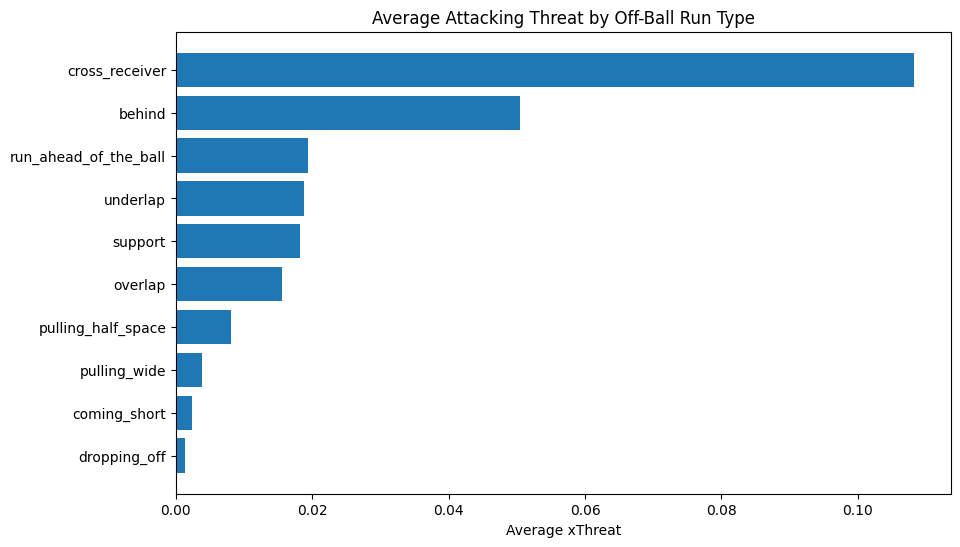

In [30]:
import matplotlib.pyplot as plt

plot_df = run_threat.sort_values("avg_xthreat", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df.index, plot_df["avg_xthreat"])
plt.xlabel("Average xThreat")
plt.title("Average Attacking Threat by Off-Ball Run Type")
plt.show()

### Interpreting the Threat of Different Run Types

The chart shows that some off-ball runs create much more attacking danger than others. Cross-receiver runs generate the highest average attacking threat. These runs usually occur when attackers move into the penalty area to receive a cross or cut-back, often leading directly to shots.

Runs in behind are also very dangerous because they break the defensive line and move attackers closer to goal. In contrast, runs such as coming short or dropping off create much less direct threat. These movements are mainly used to support build-up play and help teams keep possession rather than immediately create chances.

This result highlights that movements attacking the space close to goal are the most valuable in terms of creating scoring opportunities.

## Total Attacking Threat Generated by Run Type

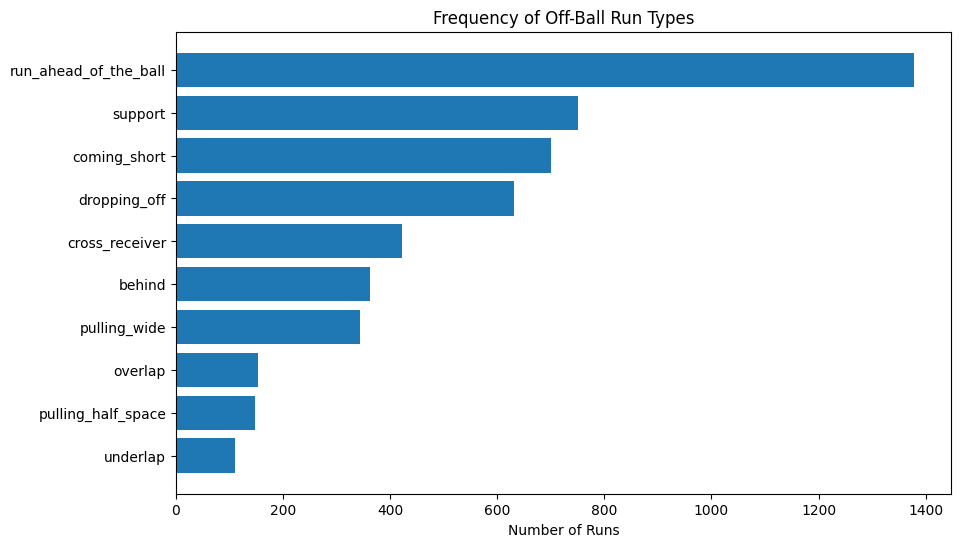

In [31]:
plot_df = run_threat.sort_values("total_runs", ascending=True)

plt.figure(figsize=(10,6))

plt.barh(plot_df.index, plot_df["total_runs"])

plt.xlabel("Number of Runs")
plt.title("Frequency of Off-Ball Run Types")

plt.show()

### Interpreting the Frequency of Run Types

While some runs are very dangerous, they do not happen as often. The chart shows that runs ahead of the ball, support runs, and coming short runs occur much more frequently during matches. These movements help teams progress the ball and create passing options during build-up play.

In contrast, highly dangerous runs such as cross-receiver runs or runs in behind occur less often because they usually happen closer to goal and at key attacking moments.

This means that some runs are important for maintaining attacking structure, while others are more directly linked to creating goal-scoring chances.

## Total Attacking Threat Generated by Run Type

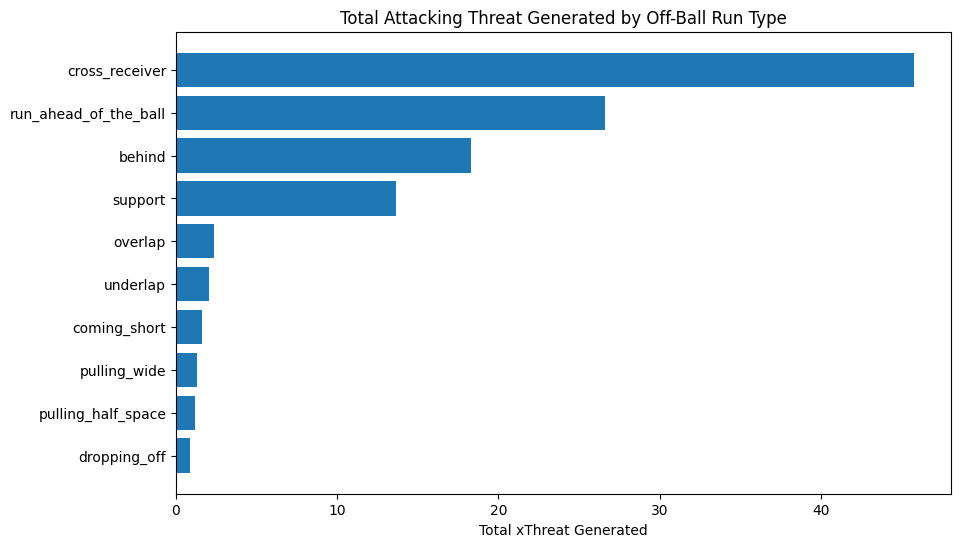

In [32]:
plot_df = run_threat.sort_values("total_xthreat", ascending=True)

plt.figure(figsize=(10,6))

plt.barh(plot_df.index, plot_df["total_xthreat"])

plt.xlabel("Total xThreat Generated")
plt.title("Total Attacking Threat Generated by Off-Ball Run Type")

plt.show()

### Interpreting Total Attacking Threat from Off-Ball Runs

This chart shows the total attacking threat generated by each run type across all matches. The value combines both how dangerous a run is on average and how often it occurs during matches.

Cross-receiver runs generate the highest overall attacking threat. These runs frequently occur inside the penalty area and often lead directly to shots or high-quality chances.

Runs ahead of the ball appear second in total impact. Although each individual run is less dangerous than a cross-receiver run, this movement happens much more frequently during attacks, especially during build-up and progression phases.

Runs in behind also generate significant attacking threat because they break defensive lines and create direct opportunities close to goal.

This result highlights that some movements are valuable because they are highly dangerous, while others contribute through their frequency during attacking sequences.

## Run Type Value: Frequency vs Attacking Threat

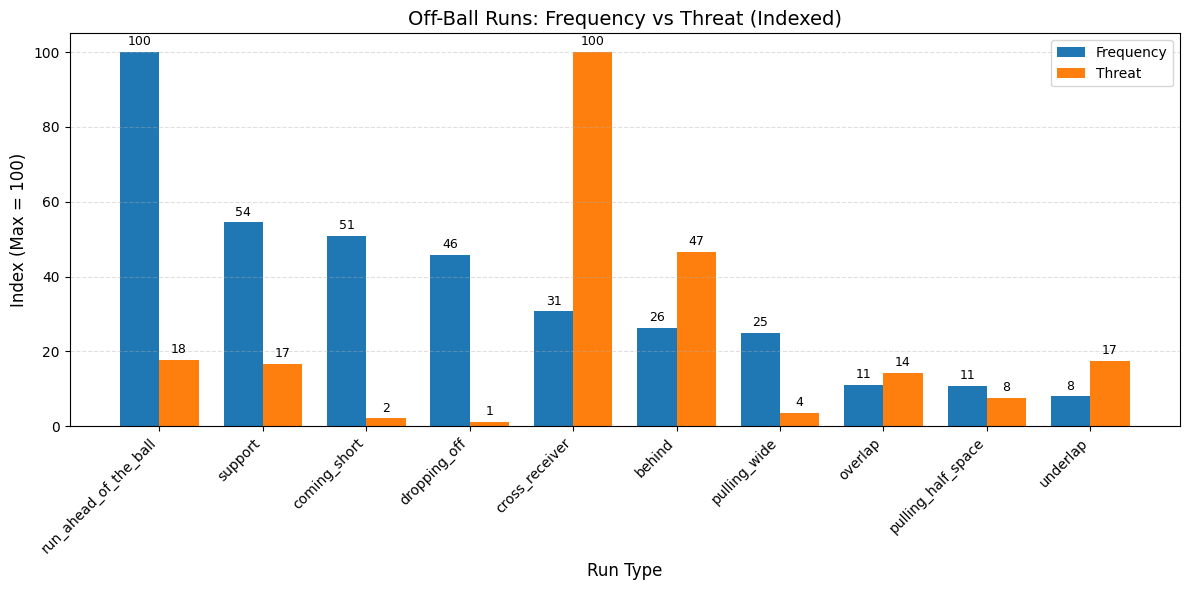

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Create indexed comparison dataset
plot_df = run_threat.copy()

plot_df["frequency_index"] = (
    plot_df["total_runs"] / plot_df["total_runs"].max() * 100
)
plot_df["threat_index"] = (
    plot_df["avg_xthreat"] / plot_df["avg_xthreat"].max() * 100
)

# Sort by frequency
plot_df = plot_df.sort_values("frequency_index", ascending=False)

x = np.arange(len(plot_df.index))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 6))

# Bars
bars1 = ax.bar(
    x - width / 2,
    plot_df["frequency_index"],
    width,
    label="Frequency",
    color="#1f77b4"
)

bars2 = ax.bar(
    x + width / 2,
    plot_df["threat_index"],
    width,
    label="Threat",
    color="#ff7f0e"
)

# Titles and labels
ax.set_title("Off-Ball Runs: Frequency vs Threat (Indexed)", fontsize=14)
ax.set_xlabel("Run Type", fontsize=12)
ax.set_ylabel("Index (Max = 100)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=45, ha="right")
ax.legend()

# Light grid for readability
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Add value labels on top of bars
for bar in list(bars1) + list(bars2):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Comparing Run Frequency and Attacking Threat

This chart compares how frequently different off-ball runs occur with the attacking threat they generate.

Runs ahead of the ball occur most often during matches, highlighting their role in supporting attacking progression and offering passing options for the ball carrier. However, these movements tend to generate relatively low direct attacking threat.

Cross-receiver runs produce the highest attacking threat. These runs usually occur inside the penalty area when attackers move to receive crosses or cut-backs, which frequently leads to shots or high-value scoring opportunities.

Runs in behind provide a balanced profile by generating relatively high attacking threat while also occurring regularly during attacking phases. These movements often break defensive lines and create space close to goal.

Overall, the chart highlights that different off-ball movements serve different tactical purposes: some support build-up play, while others are directly associated with creating goal-scoring chances.

## Player Run Threat per 90 Minutes

In [34]:
import json

# Build player minutes dataset from all match metadata files

# Load the matches data from matches.json
matches_file_path = "opendata/data/matches.json"
with open(matches_file_path, "r") as f:
    matches = json.load(f)

player_minutes = []

for match in matches:
    match_id = match["id"]
    match_folder = f"opendata/data/matches/{match_id}"
    match_file = f"{match_folder}/{match_id}_match.json"

    with open(match_file, "r") as f:
        match_data = json.load(f)

    for player in match_data["players"]:
        minutes_played = 0 # Default to 0 minutes if data is missing
        if player["playing_time"] and player["playing_time"]["total"]:
            minutes_played = player["playing_time"]["total"]["minutes_played_regular_time"]

        player_minutes.append(
            {
                "match_id": match_id,
                "player_name": player["short_name"],
                "player_position": player["player_role"]["acronym"],
                "minutes_played": minutes_played,
            }
        )

player_minutes_df = pd.DataFrame(player_minutes)

# Aggregate total minutes across all matches
player_minutes_total = (
    player_minutes_df.groupby(["player_name", "player_position"], as_index=False)
    .agg(total_minutes=("minutes_played", "sum"))
)

# Aggregate run threat across all matches
player_run_threat = (
    runs.groupby(["player_name", "player_position"], as_index=False)
    .agg(
        total_runs=("event_subtype", "count"),
        total_xthreat=("xthreat", "sum"),
        shots=("lead_to_shot", "sum"),
        goals=("lead_to_goal", "sum"),
    )
)

# Merge player minutes with run threat
player_run_threat_90 = player_run_threat.merge(
    player_minutes_total,
    on=["player_name", "player_position"],
    how="left"
)

# Calculate per 90 metrics
player_run_threat_90["runs_per90"] = (
    player_run_threat_90["total_runs"] / player_run_threat_90["total_minutes"] * 90
)

player_run_threat_90["xthreat_per90"] = (
    player_run_threat_90["total_xthreat"] / player_run_threat_90["total_minutes"] * 90
)

# Apply minimum minutes threshold
player_run_threat_90 = player_run_threat_90[
    player_run_threat_90["total_minutes"] >= 60
].copy()

# Sort by attacking threat per 90
player_run_threat_90 = player_run_threat_90.sort_values(
    "xthreat_per90", ascending=False
)

# Show top players
player_run_threat_90.head(20)


,player_name,player_position,total_runs,total_xthreat,shots,goals,total_minutes,runs_per90,xthreat_per90
8,A. Goodwin,CF,21,2.1578,4,1,60.65,31.162407,3.202012
176,P. Klimala,CF,27,1.9931,6,3,83.40,29.136691,2.150827
17,A. Segecic,LW,50,2.2057,10,0,94.65,47.543582,2.097338
136,M. Caputo,CF,41,1.9596,7,1,86.13,42.842215,2.047649
149,M. Ruhs,CF,47,3.1584,8,2,145.48,29.076162,1.953918
160,N. Botić,CF,65,3.9588,17,3,194.48,30.080214,1.832024
117,K. Rahmani,LW,35,1.2570,4,1,64.12,49.126638,1.764348
124,L. Gillion,LW,88,3.8160,13,2,194.95,40.625801,1.761682
169,N. Vergos,CF,43,2.9280,8,0,153.35,25.236387,1.718422
3,A. Bugarija,CF,29,1.2771,3,0,67.75,38.523985,1.696517


### Player Run Threat per 90 Minutes

To fairly compare players, off-ball run production and attacking threat were normalized per 90 minutes played. This adjustment removes the bias caused by players accumulating more total runs simply because they played more minutes.

A minimum playing time threshold of **60 minutes** was applied to avoid distortions from very small sample sizes. Without this filter, players with only a few minutes of playing time could appear artificially dominant when values are scaled to a full match.

The results highlight several attacking players who generate high levels of run-based attacking threat relative to their playing time. Many of the top profiles are **centre-forwards and wide attackers**, which is expected given their tactical roles in attacking phases.

Players such as **A. Goodwin, P. Klimala, M. Caputo, and N. Botić** appear among the most impactful runners in the dataset. These players combine frequent off-ball movement with actions that increase attacking threat, often through runs into dangerous areas such as the penalty box or spaces behind the defensive line.

Normalizing performance per 90 minutes provides a clearer view of which players are **most effective at generating attacking value through movement**, rather than simply identifying those who accumulated the most total actions.

## Player Run Profiles

### Building Player Run Profiles

To better understand how players generate attacking threat through movement, we construct **player run profiles**. Instead of only counting the total number of runs, we break down the distribution of **off-ball run types performed by each player**.

Each run event is categorized by its subtype (for example *run ahead of the ball*, *cross receiver*, *support*, or *runs behind*). By aggregating these events for each player, we can observe how different attackers move during possession phases.

This step groups all run events by player and run subtype and then reshapes the data into a **player-by-run-type table**, where each column represents a specific type of off-ball movement.

In [35]:
# Count run types per player

player_run_profiles = (
    runs.groupby(["player_name", "player_position", "event_subtype"])
    .size()
    .reset_index(name="run_count")
)

# Pivot to create run profile table
player_run_profiles = player_run_profiles.pivot_table(
    index=["player_name", "player_position"],
    columns="event_subtype",
    values="run_count",
    fill_value=0
)

# Reset index for easier viewing
player_run_profiles = player_run_profiles.reset_index()

player_run_profiles.head(20)

event_subtype,player_name,player_position,behind,coming_short,cross_receiver,dropping_off,overlap,pulling_half_space,pulling_wide,run_ahead_of_the_ball,support,underlap
0,A. Ayoubi,RW,0.0,0.0,0.0,0.0,0.0,1.0,0.0,5.0,0.0,0.0
1,A. Badolato,RW,0.0,0.0,3.0,0.0,1.0,2.0,1.0,8.0,2.0,1.0
2,A. Behich,LB,1.0,3.0,0.0,12.0,3.0,0.0,4.0,5.0,6.0,6.0
3,A. Bugarija,CF,1.0,2.0,6.0,0.0,0.0,0.0,1.0,17.0,2.0,0.0
4,A. Burke-Gilroy,LB,0.0,0.0,1.0,7.0,1.0,1.0,6.0,7.0,3.0,1.0
5,A. Cáceres,AM,0.0,6.0,0.0,1.0,1.0,1.0,1.0,8.0,15.0,3.0
6,A. Cáceres,LM,0.0,16.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,2.0
7,A. Faisal,LW,2.0,1.0,4.0,0.0,0.0,0.0,4.0,13.0,3.0,1.0
8,A. Goodwin,CF,9.0,1.0,6.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0
9,A. Kuen,CF,11.0,14.0,4.0,1.0,0.0,7.0,3.0,9.0,7.0,1.0


### Interpreting Player Run Profiles

The table above shows the distribution of off-ball run types performed by each player in the dataset.

Each column represents a specific type of attacking movement, such as runs behind the defensive line, cross-receiver runs, or support movements near the ball. The values represent the number of times a player performed each type of run across the matches analysed.

This view allows us to understand the **movement tendencies of different players**. For example:

- Some attackers perform many **runs ahead of the ball**, which often support ball progression during build-up phases.
- Others make more **runs behind the defensive line**, which aim to stretch the defence and create goal-scoring opportunities.
- Wide attackers often perform **cross receiver or pulling wide movements**, helping create space in the final third.

By building these movement profiles, we can begin to identify **how different attackers generate attacking threat through their off-ball behaviour**, rather than focusing only on actions with the ball.

### Focusing on the Most Impactful Players

The full run profile table contains all players in the dataset. However, to make the analysis clearer, we focus on the players who generated the **highest attacking threat per 90 minutes** in the previous section.

Filtering the run profiles to these players allows us to examine **how the most dangerous attackers move off the ball** and whether their attacking threat is driven by specific types of runs, such as runs behind the defensive line or movements to receive crosses.

This step therefore extracts the run profiles for the **top performers identified in the player threat analysis**.

In [36]:
top_players = player_run_threat_90["player_name"].head(15)

player_run_profiles_top = player_run_profiles[
    player_run_profiles["player_name"].isin(top_players)
]

player_run_profiles_top

event_subtype,player_name,player_position,behind,coming_short,cross_receiver,dropping_off,overlap,pulling_half_space,pulling_wide,run_ahead_of_the_ball,support,underlap
3,A. Bugarija,CF,1.0,2.0,6.0,0.0,0.0,0.0,1.0,17.0,2.0,0.0
8,A. Goodwin,CF,9.0,1.0,6.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0
17,A. Segecic,LW,18.0,3.0,5.0,0.0,0.0,0.0,1.0,22.0,1.0,0.0
18,A. Segecic,RDM,3.0,0.0,2.0,0.0,0.0,1.0,1.0,0.0,8.0,0.0
93,J. Kucharski,LW,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,2.0,0.0
94,J. Kucharski,RW,6.0,0.0,6.0,0.0,0.0,0.0,0.0,8.0,1.0,0.0
99,J. Randall,CF,10.0,0.0,8.0,0.0,0.0,3.0,0.0,12.0,2.0,1.0
116,K. Rahmani,LF,1.0,2.0,0.0,1.0,0.0,0.0,1.0,2.0,1.0,1.0
117,K. Rahmani,LW,7.0,2.0,6.0,1.0,1.0,2.0,4.0,10.0,1.0,1.0
124,L. Gillion,LW,7.0,6.0,17.0,4.0,2.0,5.0,4.0,31.0,12.0,0.0


### Run Profiles of the Most Dangerous Attackers

This table focuses only on the players who generated the highest attacking threat from off-ball runs in the previous analysis.

By isolating these players, we can examine which types of movements contribute most to attacking danger.

Several patterns start to emerge:

- Many of the top players frequently perform **runs ahead of the ball**, supporting ball progression into advanced areas.
- Some attackers combine these with **runs behind the defensive line**, which directly threaten the opponent’s defensive structure.
- Cross-receiver runs also appear frequently among high-threat players, highlighting the importance of movements that attack space in the box.

These results suggest that **different types of attacking runs contribute differently to attacking threat**, and that the most dangerous attackers often combine multiple run types rather than relying on a single movement pattern.

## Visualising Player Run Profiles

### Grouping Run Types into Movement Categories

The original dataset contains several detailed off-ball run subtypes, such as *run ahead of the ball*, *behind*, *support*, *pulling wide*, and *dropping off*. While these detailed labels are useful, visualizing all individual run types at once can make the analysis difficult to interpret.

To improve clarity, similar run types were grouped into broader **movement categories** that reflect common tactical behaviours in attacking play.

The grouping is defined as follows:

| Movement Category | Run Types Included |
|---|---|
| **Vertical Runs** | behind, run_ahead_of_the_ball |
| **Box Attacks** | cross_receiver |
| **Support Runs** | support, coming_short |
| **Width Runs** | pulling_wide, overlap, underlap |
| **Link Runs** | dropping_off, pulling_half_space |

These categories capture the main tactical purposes of off-ball movement:

- **Vertical Runs** stretch the defensive line and attack space ahead of the ball.
- **Box Attacks** represent movements into dangerous scoring zones, often to receive crosses.
- **Support Runs** provide passing options during build-up and attacking circulation.
- **Width Runs** stretch the defense horizontally and create crossing angles.
- **Link Runs** help attackers connect play between midfield and the forward line.

By grouping run types into these broader categories, the visualization highlights **player movement tendencies more clearly**, allowing us to compare how different attackers contribute to attacking movement.

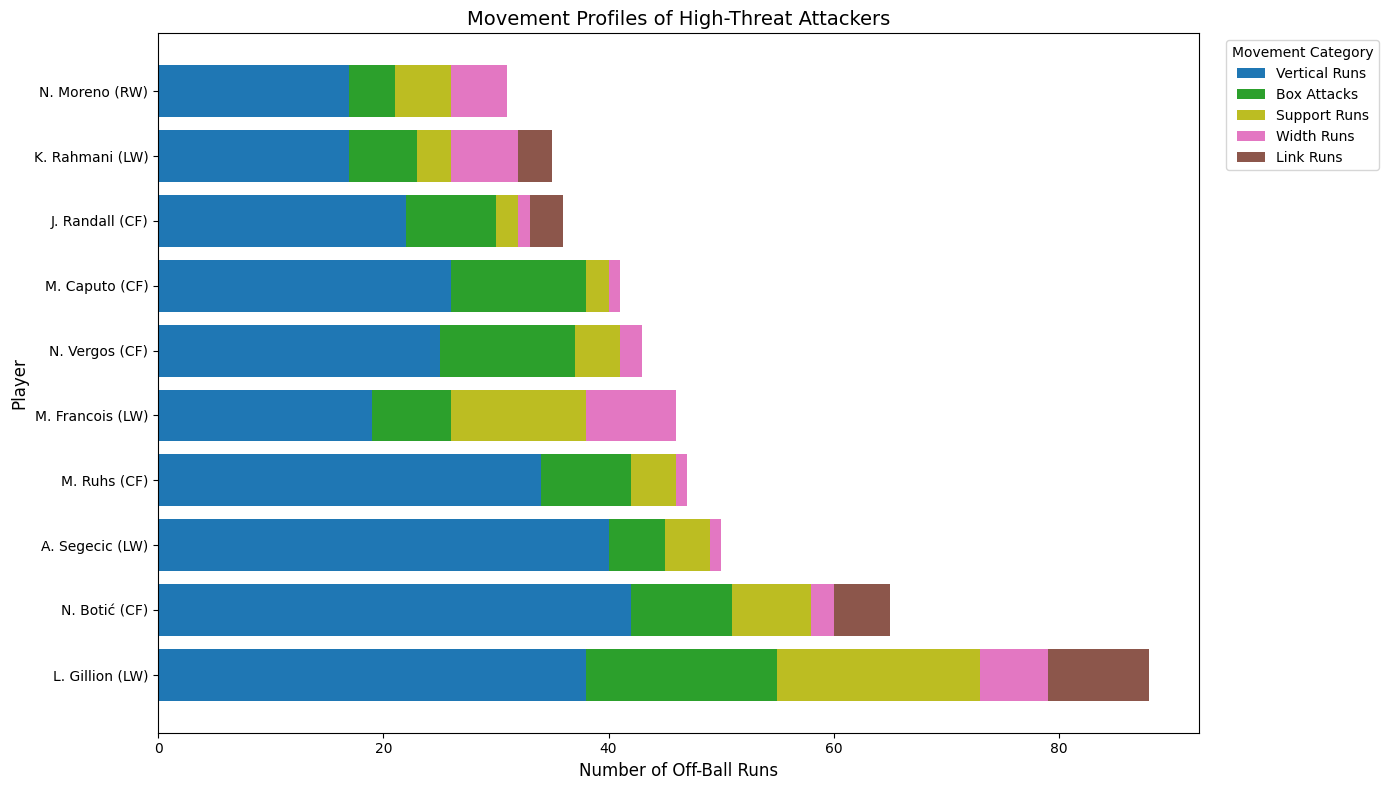

In [37]:
import matplotlib.pyplot as plt

# Copy top player profiles
player_run_profiles_top_plot = player_run_profiles_top.copy()

# Create player label
player_run_profiles_top_plot["player_label"] = (
    player_run_profiles_top_plot["player_name"]
    + " ("
    + player_run_profiles_top_plot["player_position"]
    + ")"
)

# Group run types into broader movement families
player_run_profiles_top_plot["Vertical Runs"] = (
    player_run_profiles_top_plot["behind"]
    + player_run_profiles_top_plot["run_ahead_of_the_ball"]
)

player_run_profiles_top_plot["Box Attacks"] = (
    player_run_profiles_top_plot["cross_receiver"]
)

player_run_profiles_top_plot["Support Runs"] = (
    player_run_profiles_top_plot["support"]
    + player_run_profiles_top_plot["coming_short"]
)

player_run_profiles_top_plot["Width Runs"] = (
    player_run_profiles_top_plot["pulling_wide"]
    + player_run_profiles_top_plot["overlap"]
    + player_run_profiles_top_plot["underlap"]
)

player_run_profiles_top_plot["Link Runs"] = (
    player_run_profiles_top_plot["dropping_off"]
    + player_run_profiles_top_plot["pulling_half_space"]
)

# Keep only grouped categories
plot_df = player_run_profiles_top_plot[
    [
        "player_label",
        "Vertical Runs",
        "Box Attacks",
        "Support Runs",
        "Width Runs",
        "Link Runs",
    ]
].copy()

# Add total runs and sort by total movement volume
plot_df["total_runs"] = (
    plot_df["Vertical Runs"]
    + plot_df["Box Attacks"]
    + plot_df["Support Runs"]
    + plot_df["Width Runs"]
    + plot_df["Link Runs"]
)

plot_df = plot_df.sort_values("total_runs", ascending=False).head(10)

# Plot grouped stacked bar chart
fig, ax = plt.subplots(figsize=(14, 8))

movement_cols = [
    "Vertical Runs",
    "Box Attacks",
    "Support Runs",
    "Width Runs",
    "Link Runs",
]

colors = {
    "Vertical Runs": "#1f77b4",
    "Box Attacks": "#2ca02c",
    "Support Runs": "#bcbd22",
    "Width Runs": "#e377c2",
    "Link Runs": "#8c564b",
}

bottom = None
for col in movement_cols:
    if bottom is None:
        ax.barh(
            plot_df["player_label"],
            plot_df[col],
            label=col,
            color=colors[col]
        )
        bottom = plot_df[col].copy()
    else:
        ax.barh(
            plot_df["player_label"],
            plot_df[col],
            left=bottom,
            label=col,
            color=colors[col]
        )
        bottom = bottom + plot_df[col]

ax.set_title("Movement Profiles of High-Threat Attackers", fontsize=14)
ax.set_xlabel("Number of Off-Ball Runs", fontsize=12)
ax.set_ylabel("Player", fontsize=12)
ax.legend(title="Movement Category", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

### Interpreting the Movement Profiles of High-Threat Attackers

This chart groups individual run types into broader movement categories to make player profiles easier to interpret.

The most dangerous attackers in the dataset often combine a high number of **vertical runs** with **box-attacking movements**. Vertical runs include both runs ahead of the ball and runs behind the defensive line, which help stretch the opposition and move attacks into dangerous areas. Box attacks mainly capture cross-receiver runs, which are closely linked to movements inside the penalty area.

Some players show stronger **support-run profiles**, indicating a greater role in helping ball progression and linking play. Others contribute more through **width runs**, moving into wide channels or attacking the space around the full-back. A smaller share of movements are classified as **link runs**, which reflect actions such as dropping off or pulling into supporting spaces to help connect possession.

Overall, the chart suggests that the most threatening attackers are not defined by one single movement. Instead, they combine different movement categories depending on their tactical role, with vertical and box-attacking runs appearing most strongly among the top profiles.

## Spatial Analysis of Off-Ball Runs

### Transitioning from Movement Types to Spatial Behaviour

So far, the analysis has focused on understanding *how* players move off the ball by examining different run types and player profiles.

However, off-ball movement is not only defined by the type of run, but also by **where these movements occur on the pitch**.

To extend the analysis, we now introduce the spatial dimension by examining the starting and ending locations of off-ball runs. This allows us to understand how attacking movements are distributed across the pitch and how they contribute to attacking structure.

Before visualising these patterns, we first inspect the spatial coordinates to confirm their validity and understand the pitch representation.

In [38]:
runs[["x_start", "y_start", "x_end", "y_end"]].describe()

,x_start,y_start,x_end,y_end
count,5002.000000,5002.000000,5002.000000,5002.000000
mean,4.370666,-0.017595,11.086773,-0.051675
std,19.050912,17.073255,22.686405,18.743291
min,-48.890000,-36.030000,-49.530000,-35.850000
25%,-9.535000,-12.895000,-5.817500,-16.380000
50%,5.095000,-0.085000,13.865000,-0.120000
75%,18.597500,12.990000,30.015000,16.287500
max,50.750000,34.740000,52.100000,34.550000


### Understanding the Spatial Coordinate System

The summary statistics confirm that the spatial coordinates are consistent with a standard football pitch representation.

- The **X-axis** ranges approximately from -50 to +50, representing the pitch length.
- The **Y-axis** ranges approximately from -34 to +34, representing the pitch width.
- The origin (0,0) corresponds to the **centre of the pitch**.

This means:
- Negative X values correspond to the defensive half  
- Positive X values correspond to the attacking half  

The average values show that runs tend to move forward:

- Mean x_start ≈ 4.37  
- Mean x_end ≈ 11.09  

This indicates that off-ball runs generally progress toward the attacking goal, which aligns with expected attacking behaviour.

With the spatial structure validated, we can now visualise where runs are initiated on the pitch.

### Spatial Distribution of Run Starting Locations

To better understand how attacking movements develop, we analyse where off-ball runs are initiated on the pitch.

Using the spatial coordinates of each run, we visualise the density of run starting positions. This allows us to identify the areas where attackers most frequently begin their movements and how these positions relate to attacking phases.

This step moves the analysis from *what* runs occur to *where* they originate.

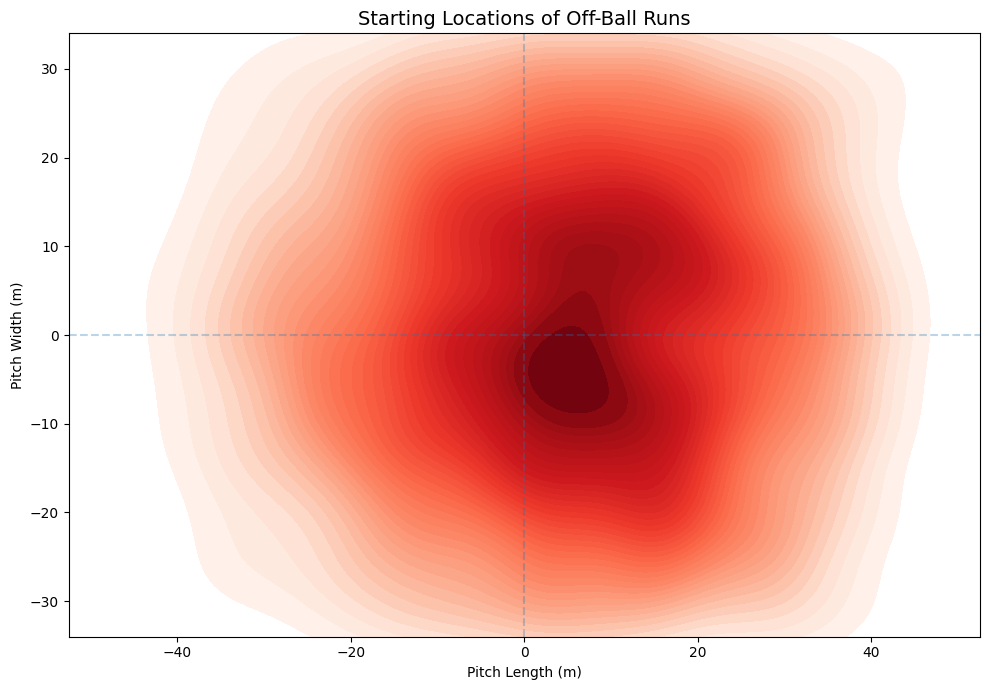

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter valid coordinates
runs_spatial = runs.dropna(subset=["x_start", "y_start"])

plt.figure(figsize=(10, 7))

sns.kdeplot(
    x=runs_spatial["x_start"],
    y=runs_spatial["y_start"],
    fill=True,
    cmap="Reds",
    levels=40,
    thresh=0.03
)

# Add pitch-like limits
plt.xlim(-52.5, 52.5)
plt.ylim(-34, 34)

plt.title("Starting Locations of Off-Ball Runs", fontsize=14)
plt.xlabel("Pitch Length (m)")
plt.ylabel("Pitch Width (m)")

plt.axhline(0, linestyle="--", alpha=0.3)
plt.axvline(0, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### Interpreting Run Starting Locations

The heatmap shows that most off-ball runs are initiated in **advanced areas of the pitch**, with the highest density concentrated approximately between:

- **X ≈ 0 to +20 metres** (from the halfway line into the attacking half)  
- **Y ≈ -10 to +10 metres** (central channels)

This indicates that attacking players typically begin their movements in **central attacking zones just beyond the halfway line**, rather than from deeper defensive positions.

The distribution also extends across wider areas of the pitch:

- **Y ≈ -25 to -10** and **Y ≈ +10 to +25**

This suggests that wide players also frequently initiate runs, particularly from positions close to the flanks. However, the central density remains slightly higher, highlighting the importance of **inside channels** as key starting zones for attacking movement.

The relatively lower density in deeper areas (X < 0) indicates that fewer runs originate from the defensive half. Instead, players are already positioned in **advanced attacking structures** before initiating off-ball movements.

Overall, the spatial distribution suggests that off-ball runs are primarily initiated from **organised attacking positions between the halfway line and the final third**, where players are best placed to exploit space ahead of the ball and support attacking progression.

### Spatial Distribution of Run Ending Locations

While starting locations show where movements begin, the ending locations of runs are more directly linked to attacking outcomes.

By analysing where runs finish, we can better understand which areas of the pitch are most frequently targeted by attacking movements and where threat is ultimately generated.

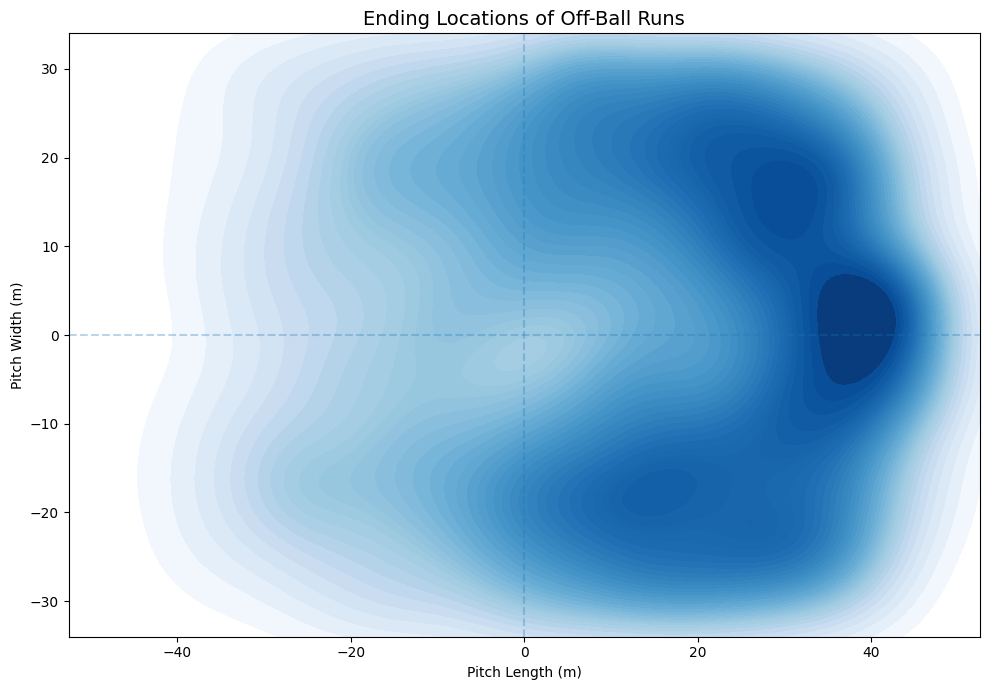

In [40]:
plt.figure(figsize=(10, 7))

sns.kdeplot(
    x=runs_spatial["x_end"],
    y=runs_spatial["y_end"],
    fill=True,
    cmap="Blues",
    levels=40,
    thresh=0.03
)

plt.xlim(-52.5, 52.5)
plt.ylim(-34, 34)

plt.title("Ending Locations of Off-Ball Runs", fontsize=14)
plt.xlabel("Pitch Length (m)")
plt.ylabel("Pitch Width (m)")

plt.axhline(0, linestyle="--", alpha=0.3)
plt.axvline(0, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### Interpreting Run Ending Locations

The heatmap shows that off-ball runs most frequently end in **advanced attacking areas**, with the highest density concentrated approximately between:

- **X ≈ +30 to +50 metres** (final third and penalty area zones)  
- **Y ≈ -10 to +10 metres** (central channels in front of goal)

This indicates that most runs are directed toward **central goal-facing areas**, which are typically associated with the highest attacking value and goal-scoring opportunities.

There is also a noticeable spread toward wider zones:

- **Y ≈ +15 to +30** and **Y ≈ -15 to -30**

This suggests that some runs finish in wide attacking areas, likely reflecting movements that support crossing situations or create space on the flanks. However, the strongest concentration remains centrally, highlighting that the ultimate target of attacking movement is often the **central corridor in front of goal**.

Compared to the starting locations, which were concentrated around **X ≈ 0 to +20**, the ending locations shift significantly forward into the final third. This confirms that off-ball runs are primarily used to **progress attacking positioning into dangerous zones**.

Overall, the spatial pattern demonstrates that off-ball runs are not only frequent but are consistently directed toward **high-value attacking areas**, reinforcing their role in creating goal-scoring opportunities.

### Linking Run Starting and Ending Locations

Comparing the starting and ending locations of off-ball runs reveals a clear spatial progression.

Runs typically begin in structured attacking areas between **X ≈ 0 and +20 metres**, before progressing into the final third, where they most frequently end between **X ≈ +30 and +50 metres**.

This shift highlights the role of off-ball movement in advancing attacking structure toward goal. While runs are initiated from relatively organised positions, their endpoints are concentrated in high-value areas, particularly in central zones in front of goal.

This suggests that off-ball runs play a key role in transforming possession from stable attacking phases into **direct goal-threatening situations**.

### Movement Progression: From Structure to Threat

By comparing the starting and ending locations of off-ball runs, we observe a clear progression pattern.

Runs typically originate from structured attacking zones (X ≈ 0–20 metres) and consistently move into high-value areas in the final third (X ≈ 30–50 metres), particularly in central channels.

This suggests that off-ball movement plays a key role in transforming stable attacking phases into direct goal-threatening situations.

## Modelling the Value of Off-Ball Runs

To better understand what drives the attacking value of off-ball movement, we model the relationship between run characteristics and the resulting attacking threat.

Using a simple regression approach, we examine how different run types and phases of play influence the xThreat generated by each run.

This allows us to quantify which types of movements are most strongly associated with dangerous attacking outcomes.

In [43]:
import pandas as pd
import statsmodels.api as sm

# Prepare dataset
df_model = runs.copy()

# Keep only needed columns
df_model = df_model[[
    "xthreat",
    "event_subtype",
    "team_in_possession_phase_type"
]].dropna()

# Convert categories to dummy variables
df_model = pd.get_dummies(
    df_model,
    columns=["event_subtype", "team_in_possession_phase_type"],
    drop_first=True
)

# Ensure all columns are numeric
df_model = df_model.astype(float)

# Define X and y
X = df_model.drop(columns=["xthreat"])
y = df_model["xthreat"]

# Add constant
X = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X).fit()

# Print summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                xthreat   R-squared:                       0.411
Model:                            OLS   Adj. R-squared:                  0.409
Method:                 Least Squares   F-statistic:                     204.9
Date:                Fri, 03 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:54:32   Log-Likelihood:                 9562.1
No. Observations:                5002   AIC:                        -1.909e+04
Df Residuals:                    4984   BIC:                        -1.897e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

### What Drives the Value of Off-Ball Runs - Regression Interpretation

To better understand what makes an off-ball run dangerous, I ran a simple regression using run type and phase of play to explain the xThreat generated by each run.

The results were quite clear.

Runs that involve attacking the box — especially cross-receiver movements — stand out as the most effective. These runs consistently lead to higher threat, which makes sense as they bring players into positions where they can directly impact goal-scoring situations.

On the other hand, more common movements like support runs or runs ahead of the ball appear less directly dangerous. They still play an important role in the build-up, but they don’t tend to lead to immediate attacking outcomes in the same way.

The context of the run also matters a lot. Runs that happen during quick attacking moments — such as quick breaks or transitions — are significantly more effective. In these situations, the opposition is often not fully organised, which makes it easier to exploit space.

Overall, the model confirms what we started to see earlier in the analysis: the value of a run is not just about how often it happens, but about where it happens and when it happens.

## Key Findings

The analysis highlights clear differences in how off-ball movements contribute to attacking threat.

First, not all runs have the same impact. Runs that involve attacking the box, particularly cross-receiver movements, consistently generate the highest levels of threat. These types of runs bring players closer to goal and are more directly linked to shots and goal-scoring situations.

In contrast, other types of movement, such as support runs or runs ahead of the ball, occur much more frequently but tend to contribute less directly to immediate attacking danger. These movements are still important, but their role appears to be more related to maintaining attacking structure and progressing the ball rather than creating final actions.

From a spatial perspective, a clear pattern emerges. Most runs begin in structured attacking areas just beyond the halfway line, typically between 0 and 20 metres in the attacking half. However, they consistently finish much further forward, mainly between 30 and 50 metres, often in central zones in front of goal. This shows that off-ball movement plays a key role in advancing attacking positioning into high-value areas.

The context in which runs occur also has a strong influence on their effectiveness. Runs performed during quick attacking phases, such as quick breaks and transitions, generate significantly more threat. This likely reflects the fact that defensive structures are less organised in these moments, making it easier for attackers to exploit space.

Overall, the findings suggest that the value of off-ball movement is not just about how often players run, but about where those runs happen and when they occur. The most effective movements are those that combine the right type of run with the right context, particularly when attacking space in the final third during fast, dynamic phases of play.

## Limitations

There are a few things to keep in mind when interpreting these results.

First, the analysis is based on event-derived tracking data, which gives a good overview of off-ball runs but does not capture the full picture. For example, we don’t have complete information about defensive positioning or pressure on the ball at every moment.

Second, xThreat is used as a way to measure attacking value. While it’s a strong indicator, it doesn’t capture everything. Some runs might be very important tactically — for example, creating space for a teammate — without directly increasing the immediate threat.

The classification of runs is also simplified. Real movements in football are often more complex than fixed categories, so some nuance is inevitably lost.

Finally, this analysis looks at general patterns across matches rather than team-specific tactics. Different teams may use off-ball movement in different ways depending on their style of play.

## Conclusion

This project set out to understand how off-ball movement contributes to attacking threat, and the results highlight how important these actions are.

Not all runs have the same impact. Movements that attack the box tend to be the most dangerous, while more frequent runs, such as support movements, play a different role in helping attacks develop.

Looking at the pitch adds another layer. Runs usually start from structured attacking positions and move into more dangerous areas in the final third, especially in central zones. This shows how off-ball movement helps turn possession into real attacking opportunities.

Timing is also key. Runs made during quick attacking phases, like transitions or quick breaks, are much more effective. These moments offer more space and less defensive organisation, which attackers can exploit.

Overall, the value of off-ball movement comes from a combination of the type of run, where it happens, and when it happens. Understanding this gives a much clearer picture of how players contribute to attacking play beyond what we see on the ball.